In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import os

from utils.mapping import SERIES_NAME_MAPPING, SERIES_NAME_MAPPING_2
from utils.plotTools import saving_manager, darken_color, format_time, format_time_label

In [2]:
experiment_id = 'ITAlert_No_Emotions'
## importing simulation results
results_dir = fr'..\results\{experiment_id}'
plot_dir = os.path.join(fr'..\plots\global_overview', experiment_id)

should_save = True

time_format = 'hh:mm' #'default', 'hh:mm', 'hh mm', r'hh\nmm'

In [3]:
all_data_temporal = []
all_data_simulation = []
all_data_volcanic = []

for folder_name in os.listdir(results_dir):
    folder_path = os.path.join(results_dir, folder_name)

    run_id = folder_name

    file_temporal = os.path.join(folder_path, 'temporal_series_recorder.csv')
    file_simulation = os.path.join(folder_path, 'simulation_recorder.csv')
    file_volcanic = os.path.join(folder_path, 'volcanic_recorder.csv')

    if os.path.exists(file_temporal):
        df_temporal = pd.read_csv(file_temporal)
        df_temporal['run_id'] = run_id
        all_data_temporal.append(df_temporal)

        df_simulation = pd.read_csv(file_simulation)
        df_simulation['run_id'] = run_id
        all_data_simulation.append(df_simulation)

        df_volcanic = pd.read_csv(file_volcanic)
        df_volcanic['run_id'] = run_id
        all_data_volcanic.append(df_volcanic)

temporal_df = pd.concat(all_data_temporal,ignore_index=True)
simulation_df = pd.concat(all_data_simulation, ignore_index=True)
volcanic_df = pd.concat(all_data_volcanic, ignore_index=True)

In [4]:
## processing temporal dataframe to be more human-readable
with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(temporal_df)

columns_to_process = ['nb_people_warned', 'nb_people_prepared']
for column_name in columns_to_process:
    temporal_df[column_name] = temporal_df['nb_evacuated_people'] + temporal_df[column_name]

with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(temporal_df)

           time  nb_humans_on_island  nb_people_on_island  nb_LEAs_on_island  nb_humans_on_board  nb_people_on_board  nb_LEAs_on_board  nb_evacuated_humans  nb_evacuated_people  nb_evacuated_LEAs  nb_people_warned  nb_people_prepared  nb_people_enjoying_their_time  nb_people_making_a_decision  nb_people_going_to_port  nb_people_rescuing_others  nb_people_waiting  nb_people_going_to_safe_area  nb_people_at_port  nb_people_who_left_the_island  nb_joyous_people  nb_fearful_people  nb_alright_people              run_id
0           0.0                  530                  500                 30                   0                   0                 0                    0                    0                  0                 0                   0                              0                            0                        0                          0                  0                             0                  0                              0                 0                 

In [5]:
with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(simulation_df)
    print('-'*115)

with pd.option_context('display.width', 1000, 'display.max_columns', None):
    print(volcanic_df.head())

    event_time                                     event_name                                              notes              run_id
0            0                       Volcanic Activity Update     Volcano LaFossawent from activity level 1 to 2                 0.2
1         1798  Population Evacuation Order - IT Alert issued  Civil defense ordered evacuation of civil popu...                 0.2
2         1799                        Backups Reached Vulcano  30 backup LEAs arrived on the Island. Ordered ...                 0.2
3        16249                          LEAs Evacuation Order  Civil defense ordered evacuation of Law Enforc...                 0.2
4        19386                     Civil Evacuation Completed  The evacuation of civil population was completed.                 0.2
5        21065                           Evacuation Completed                          Evacuation was completed.                 0.2
6            0                       Volcanic Activity Update     Vol

In [6]:
series_color = {
    "nb_humans_on_island": "#A52A2A",
    "nb_people_on_island": "#D2691E",
    "nb_LEAs_on_island": "#A0522D",
    "nb_humans_on_board": "#000080",
    "nb_people_on_board": "#4682B4",
    "nb_LEAs_on_board": "#87CEEB",
    "nb_evacuated_humans": "#006400",
    "nb_evacuated_people": "#228B22",
    "nb_evacuated_LEAs": "#3CB371",

    "nb_people_warned": "#ba8e23",
    "nb_people_prepared": "#f97c00",

    "nb_people_enjoying_their_time": "#ddf4e7",
    "nb_people_making_a_decision": "#37353e",
    "nb_people_preparing": "#cccccc",
    "nb_people_going_to_port": "#316347",
    "nb_people_rescuing_others": "#b0cebd",
    "nb_people_waiting": "#84a994",
    "nb_people_going_to_safe_area": "#5a856d",
    "nb_people_at_port": "#004225",
    "nb_people_who_left_the_island": "#EDF5F0",
    
    "nb_joyous_people": "#b4e05b",
    "nb_fearful_people": "#ff0000",
    "nb_alright_people": "#008080",
}

end_of_run_color = "#757575"

In [7]:
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['xtick.minor.size'] = 2
plt.rcParams['xtick.minor.width'] = 1.2
plt.rcParams['ytick.minor.size'] = 2
plt.rcParams['ytick.minor.width'] = 1.2
plt.rcParams['axes.linewidth'] = 1.2

# plt.rcParams['font.family'] = 'Trebuchet MS' # set the font family style
# plt.rcParams['pdf.fonttype'] = 42

## Multiple Line Plots

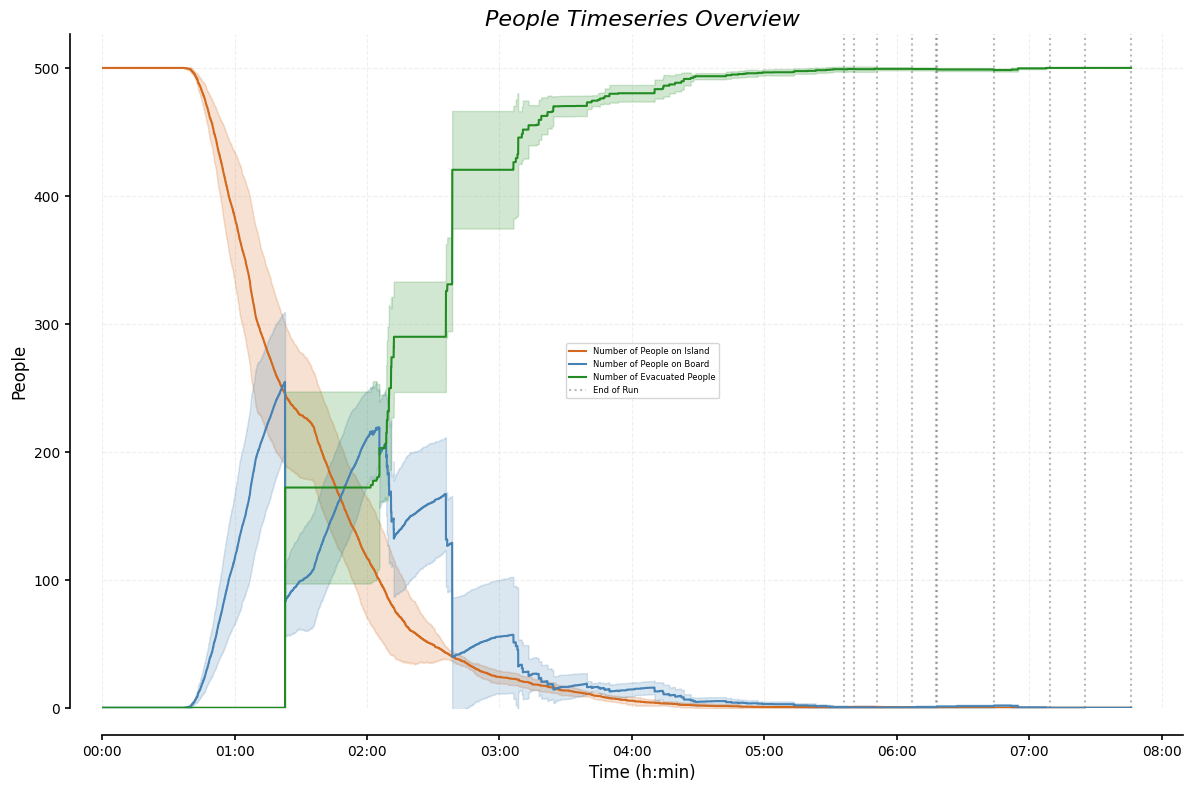

Plot saved here: ..\plots\global_overview\ITAlert_No_Emotions\people_timeseries_overview_fancy.png


In [8]:
#multiple line plot
multiple_line_plots_dict = {
    'humans_overview': {
        'columns': ['nb_humans_on_island', 'nb_humans_on_board', 'nb_evacuated_humans'],
        'title': "Humans Timeseries Overview",
        'filename': "humans_timeseries_overview",
        'ylabel': "Humans",
    },
    'people_overview': {
        'columns': ['nb_people_on_island', 'nb_people_on_board', 'nb_evacuated_people'],
        'title': "People Timeseries Overview",
        'filename': "people_timeseries_overview",
        'ylabel': "People",
    },
    'LEAs_overview': {
        'columns': ['nb_LEAs_on_island', 'nb_LEAs_on_board', 'nb_evacuated_LEAs'],
        'title': "LEAs Timeseries Overview",
        'filename': "LEAs_timeseries_overview",
        'ylabel': "Law Enforcement Agents",
    },
    'evacuation_order_progress': {
        'columns': ['nb_people_warned'],
        'title': "Evacuation Order Progress",
        'filename': "evacuation_order_progress",
        'ylabel': "Warned People",
    },

} 

selected_plot = 'people_overview'
make_it_fancy = True

plot_dict = multiple_line_plots_dict[selected_plot]
columns_to_plot = plot_dict['columns']

plot_df = temporal_df.groupby('time')[columns_to_plot].agg(['mean', 'std']).reset_index()
df_max_time = temporal_df.groupby('run_id')['time'].max()

plt.figure(figsize=(12, 8))

for column in columns_to_plot:
    plt.plot(plot_df['time'], plot_df[(column, 'mean')], color=series_color[column], label=f'{SERIES_NAME_MAPPING[column]}', zorder=3)
    plt.fill_between(
        plot_df['time'],
        plot_df[(column, 'mean')] - plot_df[(column, 'std')],
        plot_df[(column, 'mean')] + plot_df[(column, 'std')],
        color=series_color[column],
        alpha=0.2, 
        zorder=2,
    )

first_line = True
for run_id, max_time in df_max_time.items():
    if first_line:
        plt.axvline(x=max_time, color=end_of_run_color, linestyle=':', alpha = 0.5, label=f'End of Run', zorder=1)
        first_line = False
    else:
        plt.axvline(x=max_time, color=end_of_run_color, linestyle=':', alpha = 0.5, zorder=1) 

plt.xlim(0, temporal_df['time'].max()*1.05)
plt.ylim(0)
plt.legend(fontsize=6)
plt.title(plot_dict['title'], fontsize=16, fontstyle='italic')
ax = plt.gca()
format_time_label(ax, fontsize=12, format=time_format)
plt.ylabel(plot_dict['ylabel'], fontsize=12)
plt.grid(True, linestyle='--', alpha=0.2)


time_formatter = lambda t, pos: format_time(t, format=time_format)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(time_formatter))
tick_interval = 3600
ax.xaxis.set_major_locator(mticker.MultipleLocator(tick_interval))

if make_it_fancy:
    ax = plt.gca()
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.spines['bottom'].set_position(('axes', -0.04))
    ax.spines['left'].set_position(('axes', -0.03))
plt.tight_layout()

if make_it_fancy:
    plot_filename=plot_dict['filename'] + "_fancy.png"
else:
    plot_filename=plot_dict['filename'] + ".png"
plot_filepath=os.path.join(plot_dir, plot_filename)
saving_manager(should_save=should_save, save_path=plot_filepath, should_show=True)

In [9]:
time_format = r"hh\nmm"

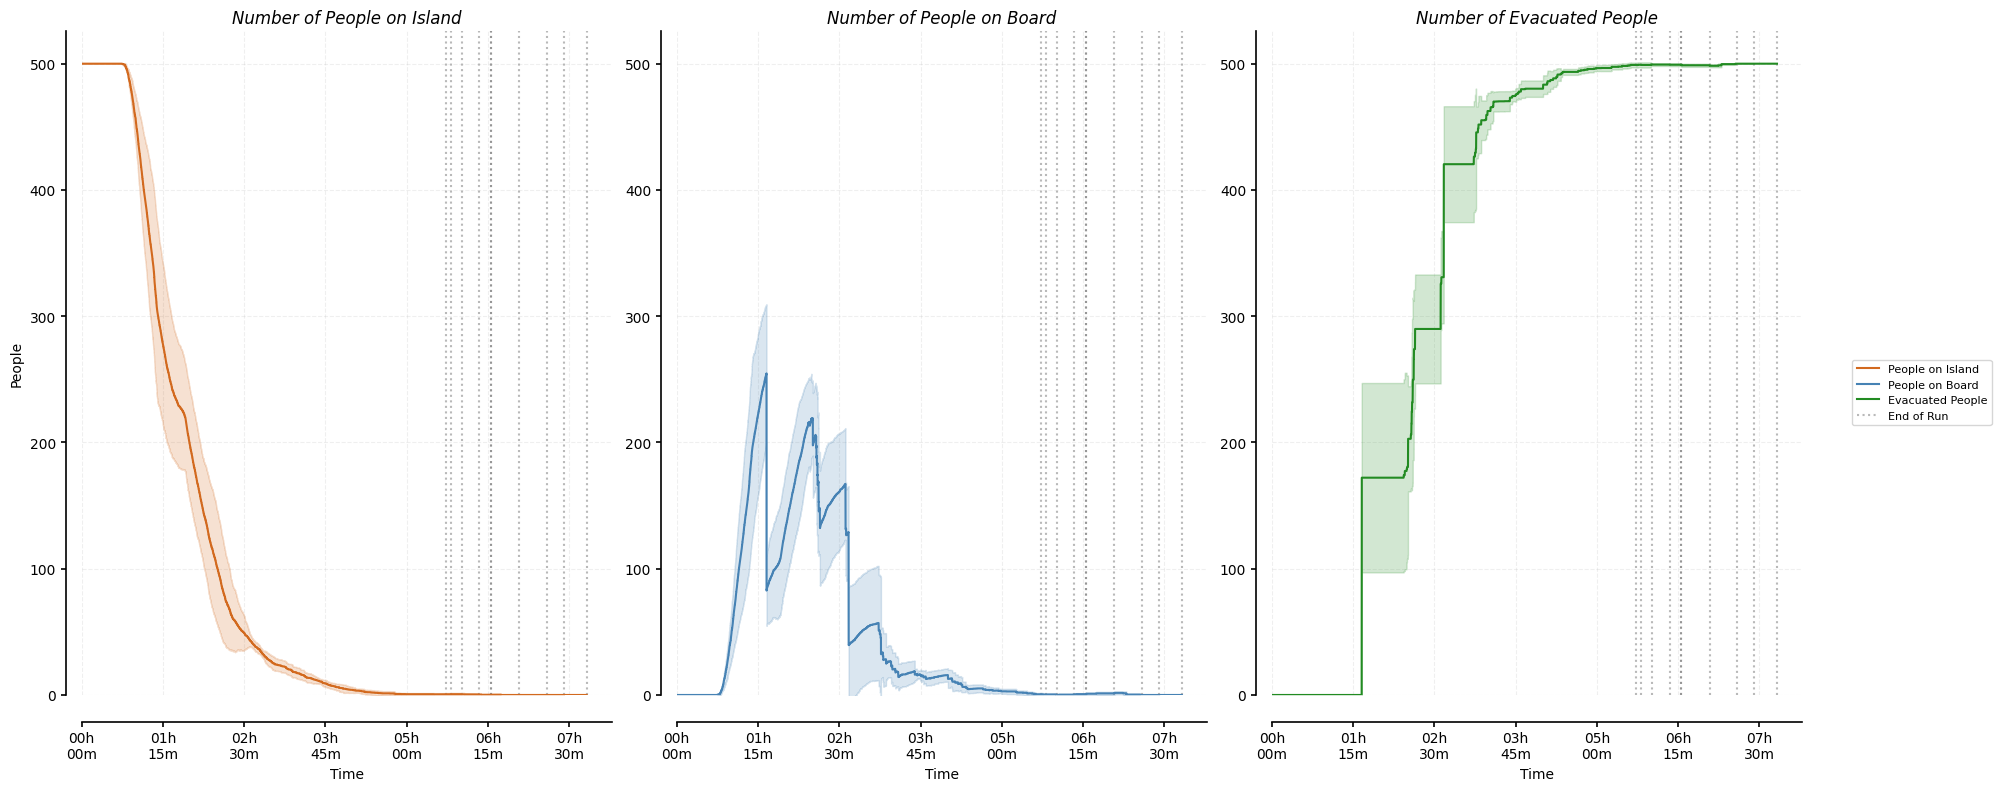

Plot saved here: ..\plots\global_overview\ITAlert_No_Emotions\people_timeseries_overview_std_subplots_fancy.png


In [10]:
plot_dict = multiple_line_plots_dict[selected_plot]
columns_to_plot = plot_dict['columns']

plot_df = temporal_df.groupby('time')[columns_to_plot].agg(['mean', 'std']).reset_index()
df_max_time = temporal_df.groupby('run_id')['time'].max()

n_subplots = len(columns_to_plot)
fig, axes = plt.subplots(1, n_subplots, figsize=(20, 8), sharey=True)

# fig.suptitle(plot_dict['title'], fontsize=16)

handles = []
labels = []
vline_handle = None

for i, column in enumerate(columns_to_plot):
    ax = axes[i]
    
    line, = ax.plot(plot_df['time'], plot_df[(column, 'mean')], color=series_color[column], label=f'{SERIES_NAME_MAPPING_2[column]}', zorder=3)
    ax.fill_between(
        plot_df['time'],
        plot_df[(column, 'mean')] - plot_df[(column, 'std')],
        plot_df[(column, 'mean')] + plot_df[(column, 'std')],
        color=series_color[column],
        alpha=0.2, 
        zorder=2,
    )
    handles.append(line)
    labels.append(f'{SERIES_NAME_MAPPING_2[column]}')
    
    for run_id, max_time in df_max_time.items():
        if vline_handle is None:
            vline_handle = ax.axvline(x=max_time, color=end_of_run_color, linestyle=':', alpha=0.5, label='End of Run', zorder=1)
        else:
            ax.axvline(x=max_time, color=end_of_run_color, linestyle=':', alpha=0.5, zorder=1)
    
    ax.set_title(f'{SERIES_NAME_MAPPING[column]}', fontsize=12, fontstyle='italic')
    ax.set_xlim(0, temporal_df['time'].max()*1.05)
    ax.set_ylim(0)
    time_formatter = lambda t, pos: format_time(t, format=time_format)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(time_formatter))
    tick_interval = 4500
    ax.xaxis.set_major_locator(mticker.MultipleLocator(tick_interval))
    format_time_label(ax, fontsize=10, format=time_format)

    ax.grid(True, linestyle='--', alpha=0.2)
    # ax.legend(fontsize=8)
    
    if i == 0:
        ax.set_ylabel(plot_dict['ylabel'], fontsize=10)

handles.append(vline_handle)
labels.append('End of Run')

if make_it_fancy:
    for ax in axes:
        ax.spines['right'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_ticks_position('left')
        ax.spines['bottom'].set_position(('axes', -0.04))
        ax.spines['left'].set_position(('axes', -0.03))

fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1, 0.55), fontsize=8)

plt.tight_layout(rect=[0, 0, 0.91, 1]) # Adjust rect to make space for suptitle

if make_it_fancy:
    plot_filename = plot_dict['filename'] + "_std_subplots_fancy.png"
else:
    plot_filename = plot_dict['filename'] + "_std_subplots.png"

plot_filepath = os.path.join(plot_dir, plot_filename)
saving_manager(should_save=should_save, save_path=plot_filepath, should_show=True)

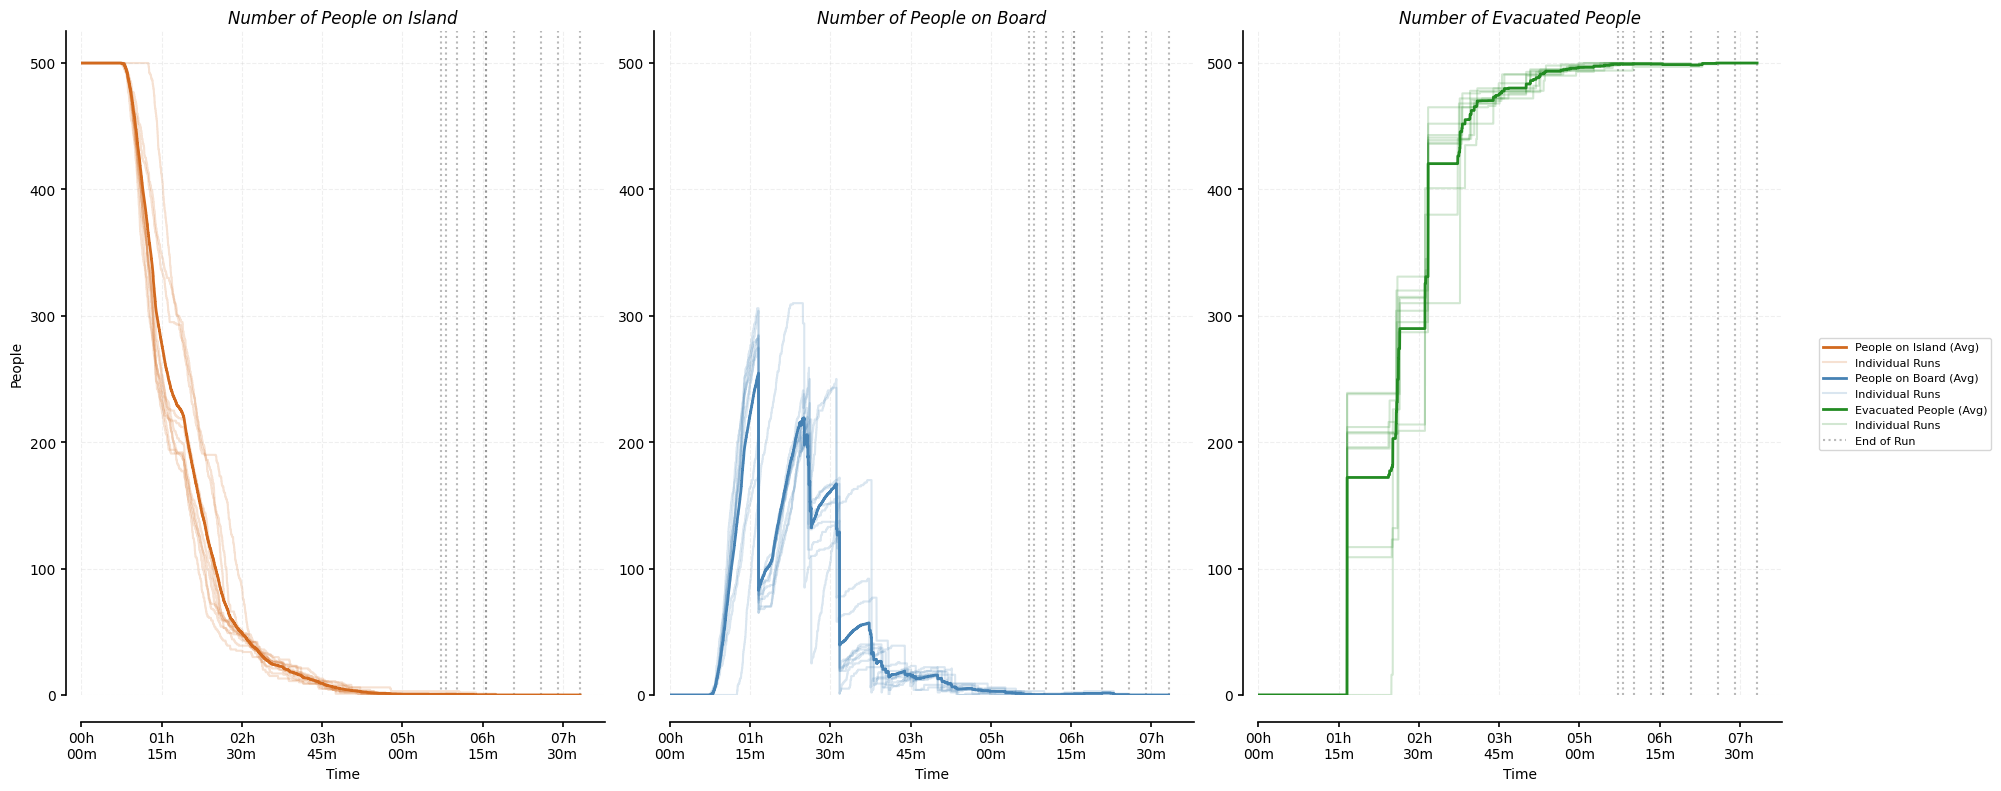

Plot saved here: ..\plots\global_overview\ITAlert_No_Emotions\people_timeseries_overview_sl_subplots_fancy.png


In [11]:
plot_dict = multiple_line_plots_dict[selected_plot]
columns_to_plot = plot_dict['columns']

plot_df_mean = temporal_df.groupby('time')[columns_to_plot].agg('mean').reset_index()
temporal_grouped_run_df = temporal_df.groupby(['time', 'run_id'])[columns_to_plot].sum().reset_index()

df_max_time = temporal_df.groupby('run_id')['time'].max()

n_subplots = len(columns_to_plot)
fig, axes = plt.subplots(1, n_subplots, figsize=(20, 8), sharey=True)

# fig.suptitle(plot_dict['title'], fontsize=16)

handles = []
labels = []
vline_handle = None
individual_run_handle = None

for i, column in enumerate(columns_to_plot):
    ax = axes[i]
    
    first_run_line = True
    for run_id in temporal_df['run_id'].unique():
        run_df = temporal_grouped_run_df[temporal_grouped_run_df['run_id'] == run_id]
        line, = ax.plot(run_df['time'], run_df[column], color=series_color[column], linestyle='-', alpha=0.2, zorder=1)
        if first_run_line:
            individual_run_handle = line
            first_run_line = False
    
    mean_line, = ax.plot(plot_df_mean['time'], plot_df_mean[column], color=series_color[column], linewidth=2, zorder=2)
    
    handles.append(mean_line)
    labels.append(f'{SERIES_NAME_MAPPING_2[column]} (Avg)')
    
    for run_id, max_time in df_max_time.items():
        if vline_handle is None:
            vline_handle = ax.axvline(x=max_time, color=end_of_run_color, linestyle=':', alpha=0.5, label='End of Run', zorder=0)
        else:
            ax.axvline(x=max_time, color=end_of_run_color, linestyle=':', alpha=0.5, zorder=0)
    
    ax.set_title(f'{SERIES_NAME_MAPPING[column]}', fontsize=12, fontstyle='italic')
    ax.set_xlim(0, temporal_df['time'].max()*1.05)
    ax.set_ylim(0)
    time_formatter = lambda t, pos: format_time(t, format=time_format)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(time_formatter))
    tick_interval = 4500
    ax.xaxis.set_major_locator(mticker.MultipleLocator(tick_interval))
    format_time_label(ax, fontsize=10, format=time_format)

    ax.grid(True, linestyle='--', alpha=0.2)
    
    if i == 0:
        ax.set_ylabel(plot_dict['ylabel'], fontsize=10)

    handles.append(individual_run_handle)
    labels.append('Individual Runs')
handles.append(vline_handle)
labels.append('End of Run')

if make_it_fancy:
    for ax in axes:
        ax.spines['right'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_ticks_position('left')
        ax.spines['bottom'].set_position(('axes', -0.04))
        ax.spines['left'].set_position(('axes', -0.03))

fig.legend(handles, labels, loc='right', bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout(rect=[0, 0, 0.90, 1])

if make_it_fancy:
    plot_filename = plot_dict['filename'] + "_sl_subplots_fancy.png"
else:
    plot_filename = plot_dict['filename'] + "_sl_subplots.png"

plot_filepath = os.path.join(plot_dir, plot_filename)
saving_manager(should_save=should_save, save_path=plot_filepath, should_show=True)

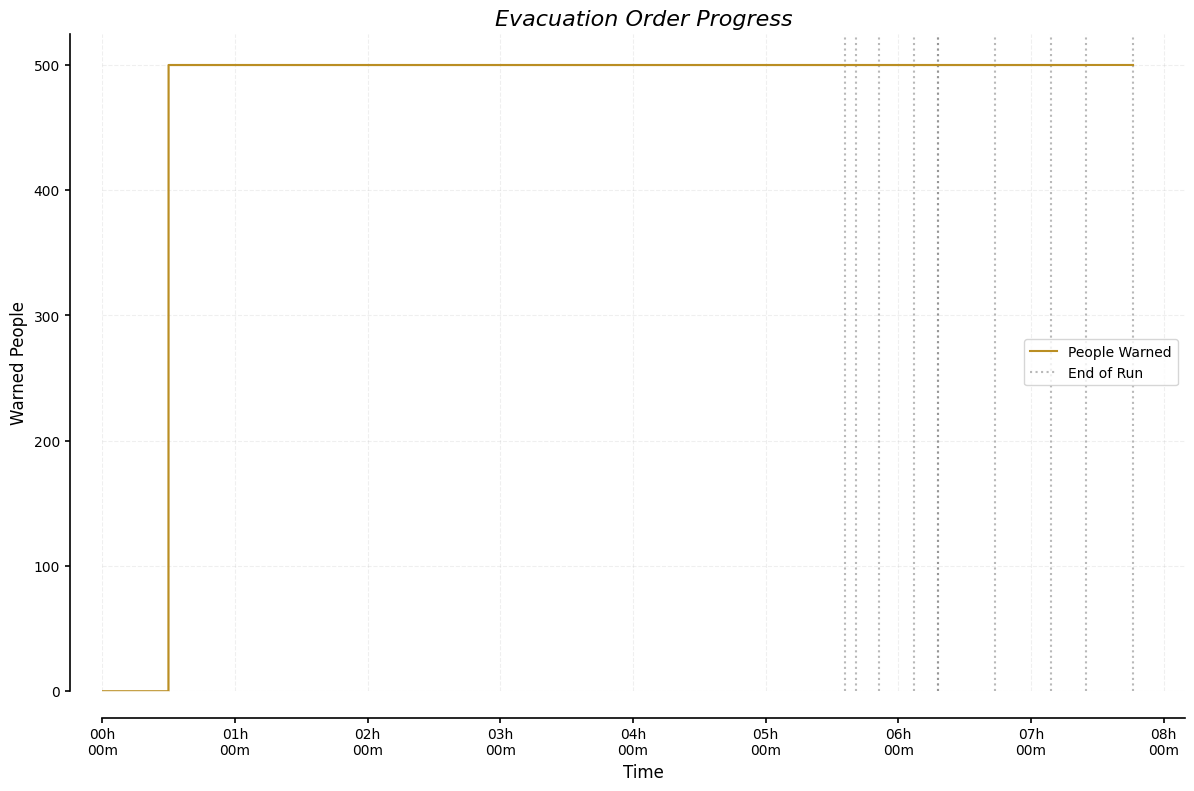

Plot saved here: ..\plots\global_overview\ITAlert_No_Emotions\evacuation_order_progress_fancy.png


In [12]:
selected_plot = 'evacuation_order_progress'

plot_dict = multiple_line_plots_dict[selected_plot]
columns_to_plot = plot_dict['columns']

plot_df = temporal_df.groupby('time')[columns_to_plot].agg(['mean', 'std']).reset_index()
df_max_time = temporal_df.groupby('run_id')['time'].max()

plt.figure(figsize=(12, 8))

for column in columns_to_plot:
    plt.plot(plot_df['time'], plot_df[(column, 'mean')], color=series_color[column], label=f'{SERIES_NAME_MAPPING_2[column]}', zorder=3)
    plt.fill_between(
        plot_df['time'],
        plot_df[(column, 'mean')] - plot_df[(column, 'std')],
        plot_df[(column, 'mean')] + plot_df[(column, 'std')],
        color=series_color[column],
        alpha=0.2, 
        zorder=2,
    )

# plt.axvline(x=1800, color='black', linestyle='-.', alpha = 0.5, label=f'IT-Alert Issuing Time', zorder=0)

first_line = True
for run_id, max_time in df_max_time.items():
    if first_line:
        plt.axvline(x=max_time, color=end_of_run_color, linestyle=':', alpha = 0.5, label=f'End of Run', zorder=1)
        first_line = False
    else:
        plt.axvline(x=max_time, color=end_of_run_color, linestyle=':', alpha = 0.5, zorder=1) 

plt.xlim(0, temporal_df['time'].max()*1.05)
plt.ylim(0)
plt.legend(fontsize=10, loc='center right')
plt.title(plot_dict['title'], fontsize=16, fontstyle='italic')
ax = plt.gca()
format_time_label(ax, fontsize=12, format=time_format)
plt.ylabel(plot_dict['ylabel'], fontsize=12)
plt.grid(True, linestyle='--', alpha=0.2)


time_formatter = lambda t, pos: format_time(t, format=time_format)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(time_formatter))
tick_interval = 3600
ax.xaxis.set_major_locator(mticker.MultipleLocator(tick_interval))

if make_it_fancy:
    ax = plt.gca()
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.spines['bottom'].set_position(('axes', -0.04))
    ax.spines['left'].set_position(('axes', -0.03))
plt.tight_layout()

if make_it_fancy:
    plot_filename=plot_dict['filename'] + "_fancy.png"
else:
    plot_filename=plot_dict['filename'] + ".png"
plot_filepath=os.path.join(plot_dir, plot_filename)
saving_manager(should_save=should_save, save_path=plot_filepath, should_show=True)